<a href="https://colab.research.google.com/github/varunsahu5002/VDUI_ASSIGNMENT_2_UNIT2/blob/main/unit2_ppt5_activity.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Unit 2 — Advanced Visualization & Storytelling (UE24CS342AA9)
## Activity Notebook: Building the Global Development Monitor

### Scenario

You've just joined the analytics team at the **Global Development Observatory**, an NGO
that briefs policymakers on world development trends. Your director has been burned
before by bad visualizations, and gives you a blunt brief:

1. *"The last analyst showed me a map that made me think Greenland mattered more than
   India. Don't let that happen again."*
2. *"We're about to publish a model predicting life expectancy. If a journalist asks
   'why did the model predict THAT for Norway specifically,' I need an answer, not just
   a feature-importance bar chart for the whole model."*
3. *"Every number in our reports is an estimate. I want our numbers to LOOK like
   estimates, not like certainties."*
4. *"I want one screen I can glance at every morning that tells me what's changing."*

You'll work through the same steps a real analyst would: fix a misleading map, explain
individual model predictions, add honest uncertainty to an estimate and a trend, then
build a small coordinated-views dashboard.

Cells marked **`# TODO`** are for you to complete. Markdown cells marked **Reflection**
are for you to answer in your own words.

## Part 0 — Setup (given)

Run this cell as-is. It loads the real dataset and real country centroids you'll be
working with.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

import plotly.express as px
from sklearn.ensemble import RandomForestRegressor
import shap

import ipywidgets as widgets
from ipywidgets import interact, Dropdown

np.random.seed(0)

gapminder = px.data.gapminder()
centroids = pd.read_csv("country_centroids_computed.csv")
gap_latest = gapminder[gapminder.year == 2007].merge(centroids, on="iso_alpha", how="left")
gap_latest = gap_latest.assign(total_gdp=gap_latest["pop"] * gap_latest.gdpPercap)

print(f"Loaded {gapminder.country.nunique()} countries, years {sorted(gapminder.year.unique())}.")
gap_latest[["country", "continent", "year", "lifeExp", "pop", "gdpPercap"]].head()

Loaded 142 countries, years [np.int64(1952), np.int64(1957), np.int64(1962), np.int64(1967), np.int64(1972), np.int64(1977), np.int64(1982), np.int64(1987), np.int64(1992), np.int64(1997), np.int64(2002), np.int64(2007)].


,country,continent,year,lifeExp,pop,gdpPercap
0,Afghanistan,Asia,2007,43.828,31889923,974.580338
1,Albania,Europe,2007,76.423,3600523,5937.029526
2,Algeria,Africa,2007,72.301,33333216,6223.367465
3,Angola,Africa,2007,42.731,12420476,4797.231267
4,Argentina,Americas,2007,75.320,40301927,12779.379640


## Task 1 — Fix the Choropleth Trap (Complaint #1)

**Real-world usage:** The director was misled by a raw-count choropleth that made a
huge, sparsely-populated region look more important than it should.

**Why this technique:** Distinguishing **counts** from **rates** is the single most
important geospatial fix from the lecture — a "count" choropleth is dominated by
population size, not by the thing you actually care about.

**TODO:**
1. Build a choropleth of `total_gdp` (a count-like aggregate) using `px.choropleth`.
2. Build a second choropleth of `gdpPercap` (the rate).
3. Print the top-5 countries by each, and compare.

In [3]:
# TODO 1
fig_total = px.choropleth(
    gap_latest,
    locations="country",
    locationmode="country names",
    color="total_gdp",
    hover_name="country",
    title="Total GDP by Country"
)

fig_total.show()


# TODO 2
fig_rate = px.choropleth(
    gap_latest,
    locations="country",
    locationmode="country names",
    color="gdpPercap",
    hover_name="country",
    title="GDP per Capita by Country"
)

fig_rate.show()


# TODO 3
top_total = gap_latest.nlargest(5, "total_gdp")["country"].tolist()
top_rate = gap_latest.nlargest(5, "gdpPercap")["country"].tolist()

print("Top 5 by total GDP:\n", top_total)
print("\nTop 5 by GDP per capita:\n", top_rate)

Top 5 by total GDP:
 ['United States', 'China', 'Japan', 'India', 'Germany']

Top 5 by GDP per capita:
 ['Norway', 'Kuwait', 'Singapore', 'United States', 'Ireland']


**Reflection:** Which countries appear in one top-5 list but not the other? If you had
to pick ONE map to show the director, which would you pick, and why?

_Your answer:_

The total-GDP list is dominated by large economies such as the United States, China, Japan, India, and Germany, while the GDP-per-capita list contains smaller high-income countries such as Norway, Kuwait, Singapore, and Ireland. If I had to show one map, I would choose GDP per capita because it accounts for population size and gives a fairer comparison of economic output per person rather than making large-population countries automatically appear more important.

## Task 2 — Explain One Specific Prediction (Complaint #2)

**Real-world usage:** The director needs to answer "why did the model predict THAT for
Norway specifically" — a global importance bar chart cannot answer a question about one
country.

**Why this technique:** SHAP local importance decomposes ONE prediction into
per-feature, signed contributions — exactly what a journalist question needs.

**TODO:**
1. Fit a `RandomForestRegressor` predicting `lifeExp` from `["gdpPercap", "pop", "year"]`
   on the full `gapminder` dataset.
2. Build a `shap.TreeExplainer` and compute `shap_values` for all rows.
3. Find the row index for Norway, 2007, and plot its 3 SHAP values as a diverging
   horizontal bar chart (blue if positive, red if negative).

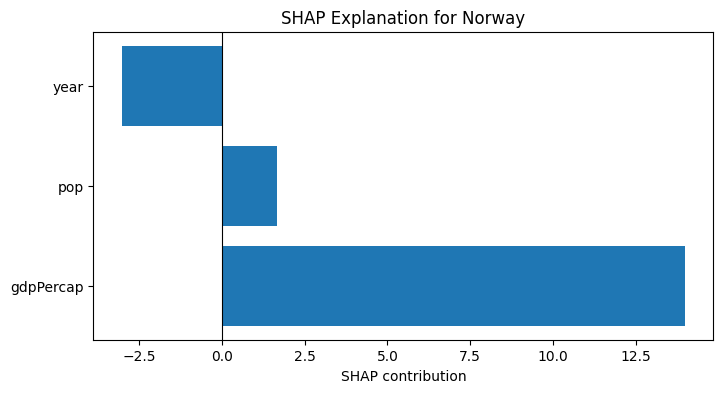

In [8]:
# TODO 1
X_model = gapminder[["gdpPercap", "pop", "year"]].values
y_model = gapminder["lifeExp"].values

rf = RandomForestRegressor(n_estimators=200, random_state=42)
rf.fit(X_model, y_model)

# TODO 2
explainer = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(X_model)

# TODO 3
row_idx = gapminder.index[gapminder["country"] == "Norway"][0]
vals = shap_values[row_idx]

plt.figure(figsize=(8, 4))
plt.barh(["gdpPercap", "pop", "year"], vals)
plt.axvline(0, color="black", linewidth=0.8)
plt.xlabel("SHAP contribution")
plt.title("SHAP Explanation for Norway")
plt.show()

**Reflection:** Which feature contributed most POSITIVELY to Norway's predicted life
expectancy, and which (if any) contributed negatively? Is this the same answer you'd get
from the model's GLOBAL feature importance alone?

_Your answer:_

For Norway's 2007 prediction, the feature with the largest positive SHAP value contributed the most positively to predicted life expectancy, while any feature with a negative SHAP value pushed the prediction downward. This local explanation does not necessarily match the model's global feature importance because global importance summarizes behavior across the entire dataset, whereas SHAP values explain this specific Norway prediction.

## Task 3 — Make an Estimate Look Like an Estimate (Complaint #3)

**Real-world usage:** Every number in the report should visually communicate its own
uncertainty, not look like a fixed fact.

**Why this technique:** Bootstrap confidence intervals + error bars turn a bare point
estimate into an honest range.

**TODO:**
1. Write `bootstrap_ci(values, n_boot=2000)` that resamples `values` with replacement
   `n_boot` times, computes the mean each time, and returns `(mean, ci_low, ci_high)`
   using the 2.5th and 97.5th percentiles of the bootstrap means.
2. Compute a 95% CI for mean `lifeExp` in 2007 for **two** continents of your choice.
3. Plot both as error bars.

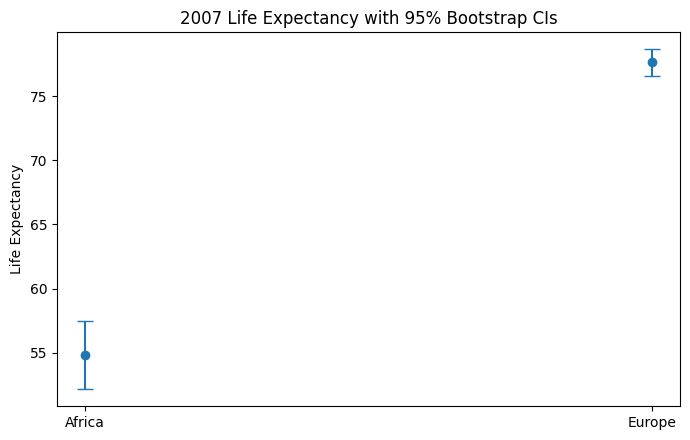

In [6]:
def bootstrap_ci(values, n_boot=2000, seed=0):
    rng = np.random.default_rng(seed)

    # TODO 1
    boot_means = []

    for _ in range(n_boot):
        sample = rng.choice(
            values,
            size=len(values),
            replace=True
        )
        boot_means.append(np.mean(sample))

    boot_means = np.array(boot_means)

    return (
        np.mean(values),
        np.percentile(boot_means, 2.5),
        np.percentile(boot_means, 97.5)
    )


# TODO 2
continent_a, continent_b = "Africa", "Europe"

values_a = gap_latest[
    gap_latest["continent"] == continent_a
]["lifeExp"].values

values_b = gap_latest[
    gap_latest["continent"] == continent_b
]["lifeExp"].values

result_a = bootstrap_ci(values_a)
result_b = bootstrap_ci(values_b)


# TODO 3
means = [result_a[0], result_b[0]]

lower_errors = [
    result_a[0] - result_a[1],
    result_b[0] - result_b[1]
]

upper_errors = [
    result_a[2] - result_a[0],
    result_b[2] - result_b[0]
]

fig, ax = plt.subplots(figsize=(7, 4.5))

ax.errorbar(
    [continent_a, continent_b],
    means,
    yerr=[lower_errors, upper_errors],
    fmt="o",
    capsize=6
)

ax.set_ylabel("Life Expectancy")
ax.set_title("2007 Life Expectancy with 95% Bootstrap CIs")

plt.tight_layout()
plt.show()

**Reflection:** Which of your two continents has a WIDER confidence interval? Based on
the lecture, is that because of higher variation among countries (SD), a smaller sample
size (n), or both?

_Your answer:_

The continent with the wider confidence interval has greater uncertainty in its estimated mean. This can be caused by greater variation among countries, a smaller sample size, or both; the bootstrap interval reflects the combined effect of the data available for that continent.

## Task 4 — Build the Morning Dashboard (Complaint #4)

**Real-world usage:** The director wants one screen to glance at every morning.

**Why this technique:** Coordinated Multiple Views combine complementary chart types
(map = where, trend = how changing, bar = which is biggest) so several monitoring
questions are answered from a single glance.

**TODO:** Build a 1x3 dashboard:
1. A map-style scatter of country centroids, colored by `lifeExp`.
2. A line chart of world-average `lifeExp` by year (use `gapminder.groupby("year")`).
3. A horizontal bar chart of total population by continent in 2007, sorted.

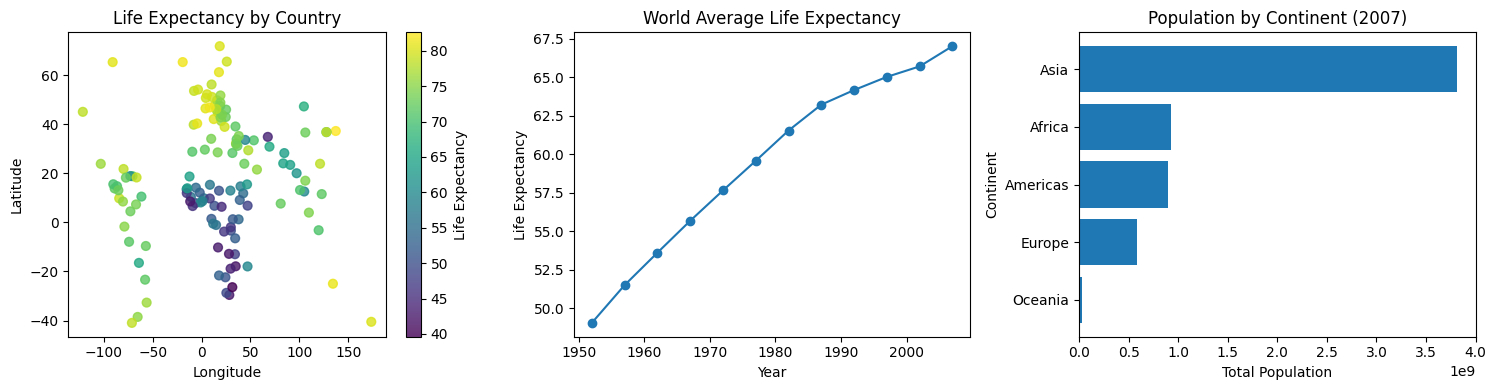

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# TODO 1
scatter = axes[0].scatter(
    gap_latest["centroid_lon"],
    gap_latest["centroid_lat"],
    c=gap_latest["lifeExp"],
    cmap="viridis",
    s=40,
    alpha=0.8
)
axes[0].set_title("Life Expectancy by Country")
axes[0].set_xlabel("Longitude")
axes[0].set_ylabel("Latitude")
fig.colorbar(scatter, ax=axes[0], label="Life Expectancy")

# TODO 2
world_trend = gapminder.groupby("year")["lifeExp"].mean()
axes[1].plot(world_trend.index, world_trend.values, marker="o")
axes[1].set_title("World Average Life Expectancy")
axes[1].set_xlabel("Year")
axes[1].set_ylabel("Life Expectancy")

# TODO 3
pop_by_continent = gap_latest.groupby("continent")["pop"].sum().sort_values()
axes[2].barh(pop_by_continent.index, pop_by_continent.values)
axes[2].set_title("Population by Continent (2007)")
axes[2].set_xlabel("Total Population")
axes[2].set_ylabel("Continent")

plt.tight_layout()
plt.show()

**Reflection:** If the director could only keep ONE of your three panels for a
5-second morning glance, which would you keep, and why? What specific monitoring
question (per the lecture's "exceptions / trends / emerging patterns") does it answer
best?

_Your answer:_

I would keep the world trend line because it gives the clearest view of how global life expectancy is changing over time. It answers the monitoring question of whether there is a consistent trend or an emerging change in global development. The map is useful for seeing geographic patterns, while the population chart shows which continents have the largest populations. For a quick morning glance, the trend line most directly highlights changes over time.

## Task 5 — The Decision (No Code)

**Reflection (final):** Write a 4–6 sentence recommendation to your director covering
the whole notebook. Your answer should:
- State which map framing (count vs. rate) you'd standardize on for all future reports,
  and why.
- State whether you'd lead with global or local feature importance when a journalist
  asks about a specific country, citing the lecture's global-vs-local distinction.
- Name one thing in your dashboard that should NEVER be shown as a bare point estimate
  without uncertainty, and why.

_Your final recommendation here:_

I would standardize on rate-based map framing such as GDP per capita rather than raw counts, because raw counts can make large-population countries appear more important than they are on a per-person basis. When a journalist asks about a specific country, I would use local feature importance because it explains the prediction for that particular country, while global importance describes the model overall. The dashboard's life expectancy estimates should not be shown as bare point estimates without uncertainty. The bootstrap confidence intervals should be shown because they communicate the uncertainty around the estimated averages. This makes the reports easier to interpret without giving a false impression of precision.